In [26]:
import cv2
import numpy as np
import math
import os
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

In [27]:
dictionary = {'clock1': 15,
               'clock2': 550,
               'clock3': 85,
               'clock4': 275,
               'clock5': 690,
               'clock6': 00,
               'clock7': 607,
               'clock8': 502,
               'clock9': 203,
               'clock10': 48,
               'clock11': 608,
               'clock12': 497,
               }

In [28]:
def Ucitavanje(path):
    global img
    img = cv2.imread(path)

    blurred = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (5, 5), 0)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return blurred

In [29]:
def FindCircles(blurred):
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp = 1.2, minDist = 100, param1 = 100, param2 = 80, minRadius = 100, maxRadius = 600) #param2=30, maxRadius=300

    circles = np.round(circles[0, :]).astype("int")
    global x
    global y
    global r
    x, y, r = circles[0]
    global center
    center = circles[0]
     


    output = img.copy()
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

    '''plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()'''

In [30]:
def LinesEdges(blurred, threshold1):
    edges = cv2.Canny(blurred, 50, 150)

    lines = cv2.HoughLinesP(edges, 1.7, np.pi / 180, threshold1, minLineLength = 30, maxLineGap = 10)

    output = img.copy()
    detected_lines = []

    for line in lines:
        x1, y1, x2, y2 = line[0]
        if (abs(x1 - x) < (r / 3) * 2 and abs(x2 - x) < (r / 3) * 2 and abs(y1 - y) < (r / 3) * 2 and abs(y2 - y) < (r / 3) * 2):
            cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
            detected_lines.append((x1, y1, x2, y2))

    '''plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()'''

    #cv2.imshow('prva', output)
    #cv2.waitKey(0)
    #cv2.destroyAllWindows()

    return detected_lines

In [31]:
def coordinate_checker(line):
    x1, y1, x2, y2 = line
    dist1 = math.sqrt((x1 - x)**2 + (y1 - y)**2)
    dist2 = math.sqrt((x2 - x)**2 + (y2 - y)**2)
    if dist1 > dist2:
        line = (x2, y2, x1, y1)

    return line

In [32]:
def DoChecker(detected_lines):
    print(detected_lines)

    for i in range(len(detected_lines)):
        detected_lines[i] = coordinate_checker(detected_lines[i])

    print(detected_lines)
    return detected_lines

In [33]:
def SamoKazaljke(detected_lines, treshold):
    print(center)
    final_lines = []
    for something in detected_lines:
        print(something)
        if (something[0] < treshold + center[0] and something[0] > center[0] - treshold) and ((something[1] < treshold + center[1] and something[1] > center[1] - treshold)):
            final_lines.append(something)

    output3 = img.copy()
    for j in range(len(final_lines)):
        cv2.line(output3, (int(final_lines[j][0]), int(final_lines[j][1])), (int(final_lines[j][2]), int(final_lines[j][3])), (255, 0, 0), 2)

    '''print(final_lines)

    plt.imshow(cv2.cvtColor(output3, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()'''

    return final_lines

In [34]:
def JednaKazaljka(final_lines, treshold):
    final_lines_copy = final_lines.copy()
    print(len(final_lines_copy))
    k = 0

    for lini in final_lines:
        k += 1
        for m in range(k, len(final_lines)):
            if not np.array_equal(lini, final_lines[m]):
                if (final_lines_copy[m][2] - treshold < lini[2] < final_lines_copy[m][2] + treshold) and (final_lines_copy[m][3] - treshold < lini[3] < final_lines_copy[m][3] + treshold):
                    if lini in final_lines_copy:
                        final_lines.remove(lini)
                    break 

    '''print(final_lines_copy)
    print(final_lines)
    print(x, y)'''

    output2 = img.copy()
    for j in range(len(final_lines)):
        x1, y1, x2, y2 = map(int, final_lines[j])
        cv2.line(output2, (x1, y1), (x2, y2), (255, 0, 0), 3)

    '''plt.imshow(cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()'''

    return final_lines

In [35]:
def Kazaljke(final_lines):
    kazaljke = []
    for (x1, y1, x2, y2) in final_lines:
        length = np.hypot(x2 - x1, y2 - y1)
        if np.hypot(x1 - x, y1 - y) > np.hypot(x2 - x, y2 - y):
            gore = np.array([x1 - x, y1 - y])
        else:
            gore = np.array([x2 - x, y2 - y])

        vec_12 = np.array([0, -1])

        proizvod = np.dot(vec_12, gore)
        pls = vec_12[0] * gore[1] - vec_12[1] * gore[0]
        angle = np.degrees(np.arctan2(pls, proizvod))
        angle += 360
        angle %= 360
        
        #print(angle)
        kazaljke.append((length, angle))

    kazaljke.sort(key=lambda x: x[0])

    return kazaljke

In [36]:
def KolikoJeSati(kazaljke):

    print(kazaljke)

    if len(kazaljke) == 1:
        sat_ugao = kazaljke[0][1]
        minut_ugao = kazaljke[0][1]

    elif len(kazaljke) == 2:
        sat_ugao = kazaljke[0][1]
        minut_ugao = kazaljke[1][1]

    elif len(kazaljke) == 3:
        sat_ugao = kazaljke[1][1]
        minut_ugao = kazaljke[2][1]
    else:
        minut_ugao = kazaljke[len(kazaljke) - 1][1]
        sat_ugao = kazaljke[len(kazaljke) - 2][1]

    sat = int((sat_ugao / 30) % 12)
    minut = int((minut_ugao / 6) % 60)
    sekund = 0
    print(f"{sat:02d}:{minut:02d}:{sekund:02d}")

    minutiUK = sat*60 + minut
    return(minutiUK)

In [ ]:
dict_locations = {'clock1': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock1.png', 
                'clock2': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock2.png',
               'clock3': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock3.png',
               'clock4': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock4.png',
               'clock5': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock5.png',
               'clock6': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock6.png',
               'clock7': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock7.jpg',
               'clock8': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock8.jpg',
               'clock9': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock9.jpg',
               'clock10': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock10.png',
               'clock11': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock11.png',
               'clock12': '/home/milan/PFE/Letnji/MAKSI vezba/Maksi vezbe-20250517T212041Z-1-001/Maksi vezbe/Citanje sata/dataset/clocks/clocks/clock12.jpg'
               }

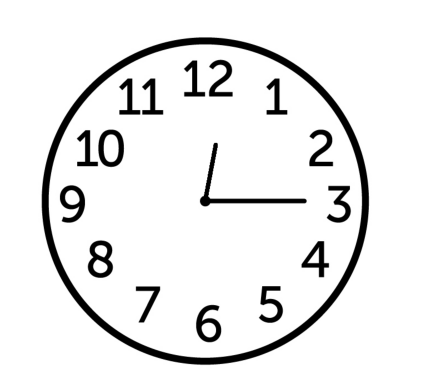

[(np.int32(360), np.int32(341), np.int32(530), np.int32(341)), (np.int32(362), np.int32(349), np.int32(532), np.int32(349)), (np.int32(197), np.int32(189), np.int32(275), np.int32(189)), (np.int32(348), np.int32(336), np.int32(366), np.int32(243)), (np.int32(357), np.int32(338), np.int32(373), np.int32(244))]
[(np.int32(360), np.int32(341), np.int32(530), np.int32(341)), (np.int32(362), np.int32(349), np.int32(532), np.int32(349)), (np.int32(275), np.int32(189), np.int32(197), np.int32(189)), (np.int32(348), np.int32(336), np.int32(366), np.int32(243)), (np.int32(357), np.int32(338), np.int32(373), np.int32(244))]
[351 346 282]
(np.int32(360), np.int32(341), np.int32(530), np.int32(341))
(np.int32(362), np.int32(349), np.int32(532), np.int32(349))
(np.int32(275), np.int32(189), np.int32(197), np.int32(189))
(np.int32(348), np.int32(336), np.int32(366), np.int32(243))
(np.int32(357), np.int32(338), np.int32(373), np.int32(244))
4
[(np.float64(95.35197952848173), np.float64(12.1714582085

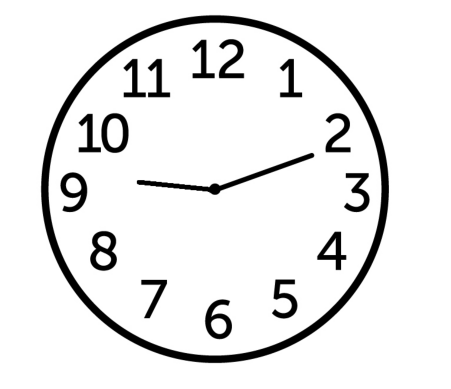

[(np.int32(398), np.int32(293), np.int32(514), np.int32(251)), (np.int32(215), np.int32(296), np.int32(335), np.int32(309)), (np.int32(362), np.int32(297), np.int32(510), np.int32(244)), (np.int32(193), np.int32(149), np.int32(270), np.int32(149)), (np.int32(356), np.int32(308), np.int32(513), np.int32(251)), (np.int32(311), np.int32(117), np.int32(344), np.int32(117)), (np.int32(273), np.int32(294), np.int32(337), np.int32(301))]
[(np.int32(398), np.int32(293), np.int32(514), np.int32(251)), (np.int32(335), np.int32(309), np.int32(215), np.int32(296)), (np.int32(362), np.int32(297), np.int32(510), np.int32(244)), (np.int32(270), np.int32(149), np.int32(193), np.int32(149)), (np.int32(356), np.int32(308), np.int32(513), np.int32(251)), (np.int32(344), np.int32(117), np.int32(311), np.int32(117)), (np.int32(337), np.int32(301), np.int32(273), np.int32(294))]
[347 307 295]
(np.int32(398), np.int32(293), np.int32(514), np.int32(251))
(np.int32(335), np.int32(309), np.int32(215), np.int32(

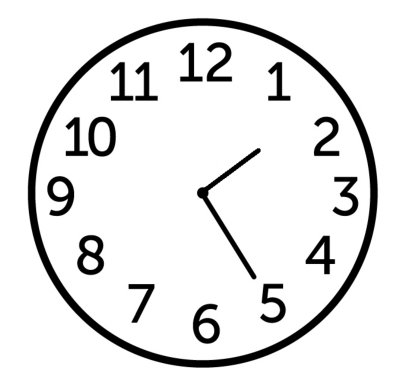

[(np.int32(323), np.int32(319), np.int32(408), np.int32(455)), (np.int32(332), np.int32(317), np.int32(414), np.int32(449)), (np.int32(334), np.int32(307), np.int32(421), np.int32(241)), (np.int32(327), np.int32(300), np.int32(417), np.int32(235)), (np.int32(170), np.int32(154), np.int32(247), np.int32(154)), (np.int32(170), np.int32(146), np.int32(247), np.int32(146)), (np.int32(289), np.int32(122), np.int32(371), np.int32(122))]
[(np.int32(323), np.int32(319), np.int32(408), np.int32(455)), (np.int32(332), np.int32(317), np.int32(414), np.int32(449)), (np.int32(334), np.int32(307), np.int32(421), np.int32(241)), (np.int32(327), np.int32(300), np.int32(417), np.int32(235)), (np.int32(247), np.int32(154), np.int32(170), np.int32(154)), (np.int32(247), np.int32(146), np.int32(170), np.int32(146)), (np.int32(289), np.int32(122), np.int32(371), np.int32(122))]
[323 309 282]
(np.int32(323), np.int32(319), np.int32(408), np.int32(455))
(np.int32(332), np.int32(317), np.int32(414), np.int32(

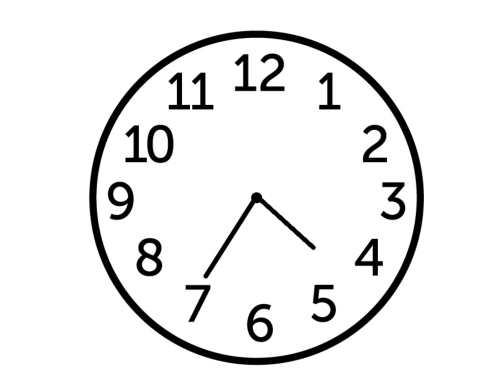

[(np.int32(347), np.int32(474), np.int32(408), np.int32(377)), (np.int32(446), np.int32(335), np.int32(538), np.int32(418)), (np.int32(340), np.int32(470), np.int32(399), np.int32(378)), (np.int32(440), np.int32(341), np.int32(532), np.int32(424)), (np.int32(280), np.int32(176), np.int32(357), np.int32(176)), (np.int32(326), np.int32(524), np.int32(345), np.int32(486)), (np.int32(345), np.int32(461), np.int32(407), np.int32(363)), (np.int32(397), np.int32(144), np.int32(482), np.int32(144)), (np.int32(346), np.int32(474), np.int32(432), np.int32(342)), (np.int32(548), np.int32(168), np.int32(578), np.int32(168))]
[(np.int32(408), np.int32(377), np.int32(347), np.int32(474)), (np.int32(446), np.int32(335), np.int32(538), np.int32(418)), (np.int32(399), np.int32(378), np.int32(340), np.int32(470)), (np.int32(440), np.int32(341), np.int32(532), np.int32(424)), (np.int32(357), np.int32(176), np.int32(280), np.int32(176)), (np.int32(345), np.int32(486), np.int32(326), np.int32(524)), (np.in

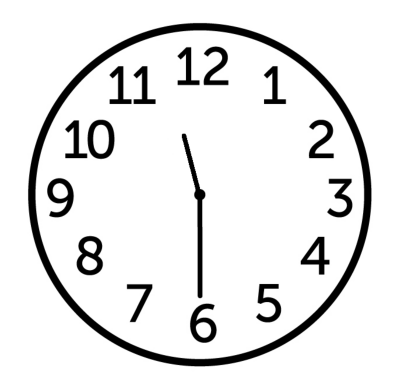

[(np.int32(321), np.int32(489), np.int32(321), np.int32(327)), (np.int32(330), np.int32(492), np.int32(330), np.int32(371)), (np.int32(171), np.int32(162), np.int32(249), np.int32(162)), (np.int32(288), np.int32(130), np.int32(373), np.int32(130)), (np.int32(439), np.int32(154), np.int32(469), np.int32(154)), (np.int32(295), np.int32(223), np.int32(318), np.int32(311))]
[(np.int32(321), np.int32(327), np.int32(321), np.int32(489)), (np.int32(330), np.int32(371), np.int32(330), np.int32(492)), (np.int32(249), np.int32(162), np.int32(171), np.int32(162)), (np.int32(288), np.int32(130), np.int32(373), np.int32(130)), (np.int32(439), np.int32(154), np.int32(469), np.int32(154)), (np.int32(318), np.int32(311), np.int32(295), np.int32(223))]
[325 319 294]
(np.int32(321), np.int32(327), np.int32(321), np.int32(489))
(np.int32(330), np.int32(371), np.int32(330), np.int32(492))
(np.int32(249), np.int32(162), np.int32(171), np.int32(162))
(np.int32(288), np.int32(130), np.int32(373), np.int32(13

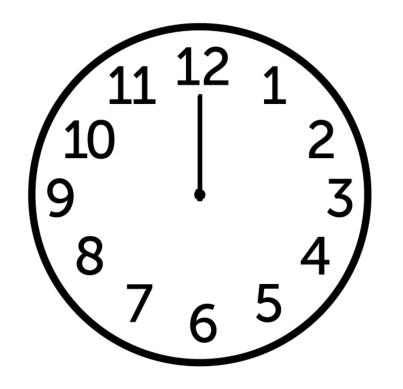

[(np.int32(321), np.int32(308), np.int32(321), np.int32(152)), (np.int32(329), np.int32(306), np.int32(329), np.int32(146)), (np.int32(436), np.int32(162), np.int32(473), np.int32(162)), (np.int32(288), np.int32(130), np.int32(373), np.int32(130)), (np.int32(439), np.int32(154), np.int32(469), np.int32(154))]
[(np.int32(321), np.int32(308), np.int32(321), np.int32(152)), (np.int32(329), np.int32(306), np.int32(329), np.int32(146)), (np.int32(436), np.int32(162), np.int32(473), np.int32(162)), (np.int32(288), np.int32(130), np.int32(373), np.int32(130)), (np.int32(439), np.int32(154), np.int32(469), np.int32(154))]
[325 319 294]
(np.int32(321), np.int32(308), np.int32(321), np.int32(152))
(np.int32(329), np.int32(306), np.int32(329), np.int32(146))
(np.int32(436), np.int32(162), np.int32(473), np.int32(162))
(np.int32(288), np.int32(130), np.int32(373), np.int32(130))
(np.int32(439), np.int32(154), np.int32(469), np.int32(154))
2
[(np.float64(160.0), np.float64(1.3245219122911749))]
00:

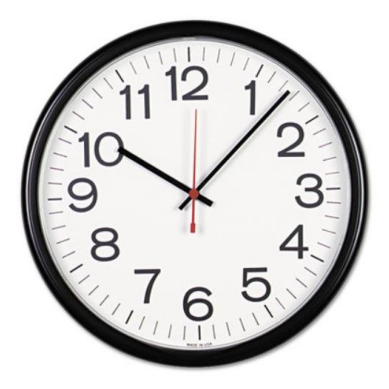

[(np.int32(256), np.int32(244), np.int32(377), np.int32(114)), (np.int32(229), np.int32(265), np.int32(374), np.int32(110)), (np.int32(145), np.int32(191), np.int32(239), np.int32(248)), (np.int32(146), np.int32(182), np.int32(273), np.int32(259)), (np.int32(246), np.int32(241), np.int32(248), np.int32(184)), (np.int32(251), np.int32(190), np.int32(252), np.int32(153)), (np.int32(249), np.int32(138), np.int32(249), np.int32(170)), (np.int32(147), np.int32(195), np.int32(225), np.int32(240)), (np.int32(249), np.int32(289), np.int32(250), np.int32(258)), (np.int32(390), np.int32(199), np.int32(390), np.int32(155)), (np.int32(147), np.int32(185), np.int32(224), np.int32(230)), (np.int32(243), np.int32(299), np.int32(246), np.int32(261)), (np.int32(389), np.int32(336), np.int32(389), np.int32(292))]
[(np.int32(256), np.int32(244), np.int32(377), np.int32(114)), (np.int32(229), np.int32(265), np.int32(374), np.int32(110)), (np.int32(239), np.int32(248), np.int32(145), np.int32(191)), (np.in

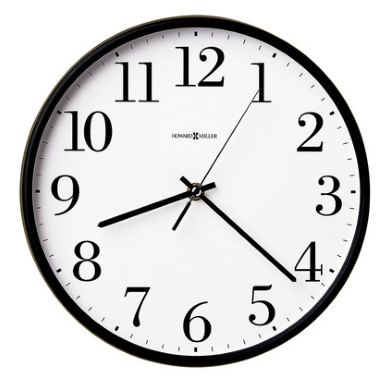

[(np.int32(177), np.int32(239), np.int32(254), np.int32(112)), (np.int32(184), np.int32(183), np.int32(286), np.int32(278)), (np.int32(224), np.int32(213), np.int32(309), np.int32(292)), (np.int32(175), np.int32(238), np.int32(257), np.int32(102)), (np.int32(95), np.int32(231), np.int32(218), np.int32(187)), (np.int32(98), np.int32(236), np.int32(211), np.int32(197)), (np.int32(254), np.int32(109), np.int32(274), np.int32(71)), (np.int32(193), np.int32(195), np.int32(289), np.int32(279))]
[(np.int32(177), np.int32(239), np.int32(254), np.int32(112)), (np.int32(184), np.int32(183), np.int32(286), np.int32(278)), (np.int32(224), np.int32(213), np.int32(309), np.int32(292)), (np.int32(175), np.int32(238), np.int32(257), np.int32(102)), (np.int32(218), np.int32(187), np.int32(95), np.int32(231)), (np.int32(211), np.int32(197), np.int32(98), np.int32(236)), (np.int32(254), np.int32(109), np.int32(274), np.int32(71)), (np.int32(193), np.int32(195), np.int32(289), np.int32(279))]
[200 197 190

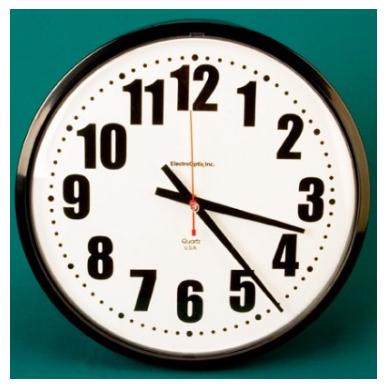

[(np.int32(208), np.int32(215), np.int32(260), np.int32(280)), (np.int32(190), np.int32(92), np.int32(191), np.int32(134)), (np.int32(224), np.int32(207), np.int32(313), np.int32(234)), (np.int32(195), np.int32(174), np.int32(195), np.int32(136)), (np.int32(190), np.int32(209), np.int32(291), np.int32(233)), (np.int32(194), np.int32(256), np.int32(194), np.int32(197)), (np.int32(192), np.int32(212), np.int32(193), np.int32(167)), (np.int32(196), np.int32(195), np.int32(197), np.int32(232)), (np.int32(191), np.int32(207), np.int32(239), np.int32(264)), (np.int32(109), np.int32(281), np.int32(109), np.int32(250))]
[(np.int32(208), np.int32(215), np.int32(260), np.int32(280)), (np.int32(191), np.int32(134), np.int32(190), np.int32(92)), (np.int32(224), np.int32(207), np.int32(313), np.int32(234)), (np.int32(195), np.int32(174), np.int32(195), np.int32(136)), (np.int32(190), np.int32(209), np.int32(291), np.int32(233)), (np.int32(194), np.int32(197), np.int32(194), np.int32(256)), (np.int3

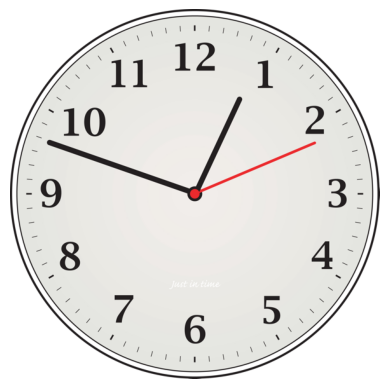

[(np.int32(298), np.int32(289), np.int32(480), np.int32(211)), (np.int32(290), np.int32(302), np.int32(365), np.int32(142)), (np.int32(290), np.int32(283), np.int32(358), np.int32(138)), (np.int32(340), np.int32(266), np.int32(437), np.int32(226)), (np.int32(112), np.int32(232), np.int32(283), np.int32(291))]
[(np.int32(298), np.int32(289), np.int32(480), np.int32(211)), (np.int32(290), np.int32(302), np.int32(365), np.int32(142)), (np.int32(290), np.int32(283), np.int32(358), np.int32(138)), (np.int32(340), np.int32(266), np.int32(437), np.int32(226)), (np.int32(283), np.int32(291), np.int32(112), np.int32(232))]
[291 289 289]
(np.int32(298), np.int32(289), np.int32(480), np.int32(211))
(np.int32(290), np.int32(302), np.int32(365), np.int32(142))
(np.int32(290), np.int32(283), np.int32(358), np.int32(138))
(np.int32(340), np.int32(266), np.int32(437), np.int32(226))
(np.int32(283), np.int32(291), np.int32(112), np.int32(232))
4
[(np.float64(160.15305179733542), np.float64(23.927273380

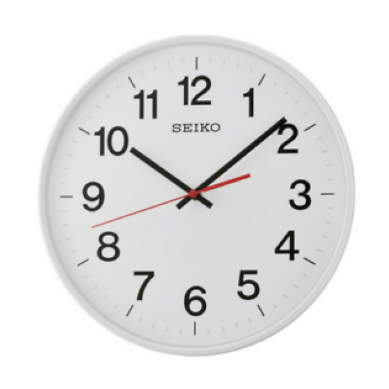

[(np.int32(134), np.int32(158), np.int32(220), np.int32(88)), (np.int32(138), np.int32(162), np.int32(224), np.int32(90)), (np.int32(72), np.int32(98), np.int32(162), np.int32(161)), (np.int32(75), np.int32(96), np.int32(156), np.int32(151))]
[(np.int32(134), np.int32(158), np.int32(220), np.int32(88)), (np.int32(138), np.int32(162), np.int32(224), np.int32(90)), (np.int32(162), np.int32(161), np.int32(72), np.int32(98)), (np.int32(156), np.int32(151), np.int32(75), np.int32(96))]
[152 151 130]
(np.int32(134), np.int32(158), np.int32(220), np.int32(88))
(np.int32(138), np.int32(162), np.int32(224), np.int32(90))
(np.int32(162), np.int32(161), np.int32(72), np.int32(98))
(np.int32(156), np.int32(151), np.int32(75), np.int32(96))
4
[(np.float64(97.9081201943945), np.float64(305.5376777919744)), (np.float64(112.16059914247963), np.float64(49.72798781884222))]
10:08:00
608
0


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [39]:
tacnost = []

for clock in dict_locations:
    blurred = Ucitavanje(dict_locations[clock])
    FindCircles(blurred)
    detected_lines = LinesEdges(blurred, 95)
    detected_lines = DoChecker(detected_lines)
    final_lines = SamoKazaljke(detected_lines, 23) #70
    final_lines = JednaKazaljka(final_lines, 23) #50
    kazaljke = Kazaljke(final_lines)
    minutUK = KolikoJeSati(kazaljke)
    print(minutUK)

    if dictionary[clock] == 0:
        tacno = 00
    else:
        tacno = abs(minutUK - dictionary[clock])
    tacnost.append(tacno)

    print(tacno)

print(f'Srednja greska svih satova je: {sum(tacnost) / len(tacnost)} [min].')

print(f'Srednja greska prvih 6 satova je: {sum(tacnost[0:6]) / len(tacnost[0:6])} [min].')
